# Vision Transformer (ViT) From Scratch

This notebook builds a Vision Transformer in a style similar to `25AI92F02_Assignment8.py`:
- clean modular classes
- explicit training and inference helpers
- end-to-end evaluation

## Sample Vision Task
**CIFAR-10 image classification** (10 classes, 32x32 RGB images).

## Hardware-aware setup (your machine)
- CPU: Ryzen 5 9600X
- RAM: 32 GB
- GPU: RTX 5070 (12 GB)

Hyperparameters are tuned to use this GPU effectively while staying stable for local runs.

## Imports

In [1]:
import os
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms

## Seeding And Device

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Favor speed on GPU for local training runs.
torch.backends.cudnn.benchmark = torch.cuda.is_available()

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
AMP_DTYPE = torch.float16 if device.type == "cuda" else torch.bfloat16

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Device:", device)
print("AMP enabled:", USE_AMP)
print("Autocast dtype:", AMP_DTYPE)

Torch version: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Device: cuda
AMP enabled: True
Autocast dtype: torch.float16


## Load CIFAR-10 Dataset

In [3]:
IMG_SIZE = 32
NUM_CLASSES = 10

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Two train splits with different transforms: augmented (train) and clean (val).
train_dataset_aug = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
train_dataset_eval = datasets.CIFAR10(root="./data", train=True, download=True, transform=eval_transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=eval_transform)

n_total = len(train_dataset_aug)
n_val = 5000
n_train = n_total - n_val

indices = torch.randperm(n_total, generator=torch.Generator().manual_seed(SEED))
train_indices = indices[:n_train].tolist()
val_indices = indices[n_train:].tolist()

train_set = Subset(train_dataset_aug, train_indices)
val_set = Subset(train_dataset_eval, val_indices)

BATCH_SIZE = 256 if device.type == "cuda" else 128
NUM_WORKERS = min(8, os.cpu_count() or 2)
PIN_MEMORY = device.type == "cuda"

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

class_names = test_dataset.classes

print(f"Train samples: {len(train_set)}")
print(f"Val samples:   {len(val_set)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Batches -> Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")

100%|██████████| 170M/170M [00:35<00:00, 4.81MB/s] 
f:\PhD Stuff\DL Lab\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 45000
Val samples:   5000
Test samples:  10000
Batches -> Train: 176, Val: 20, Test: 40
Batch size: 256 | Workers: 8


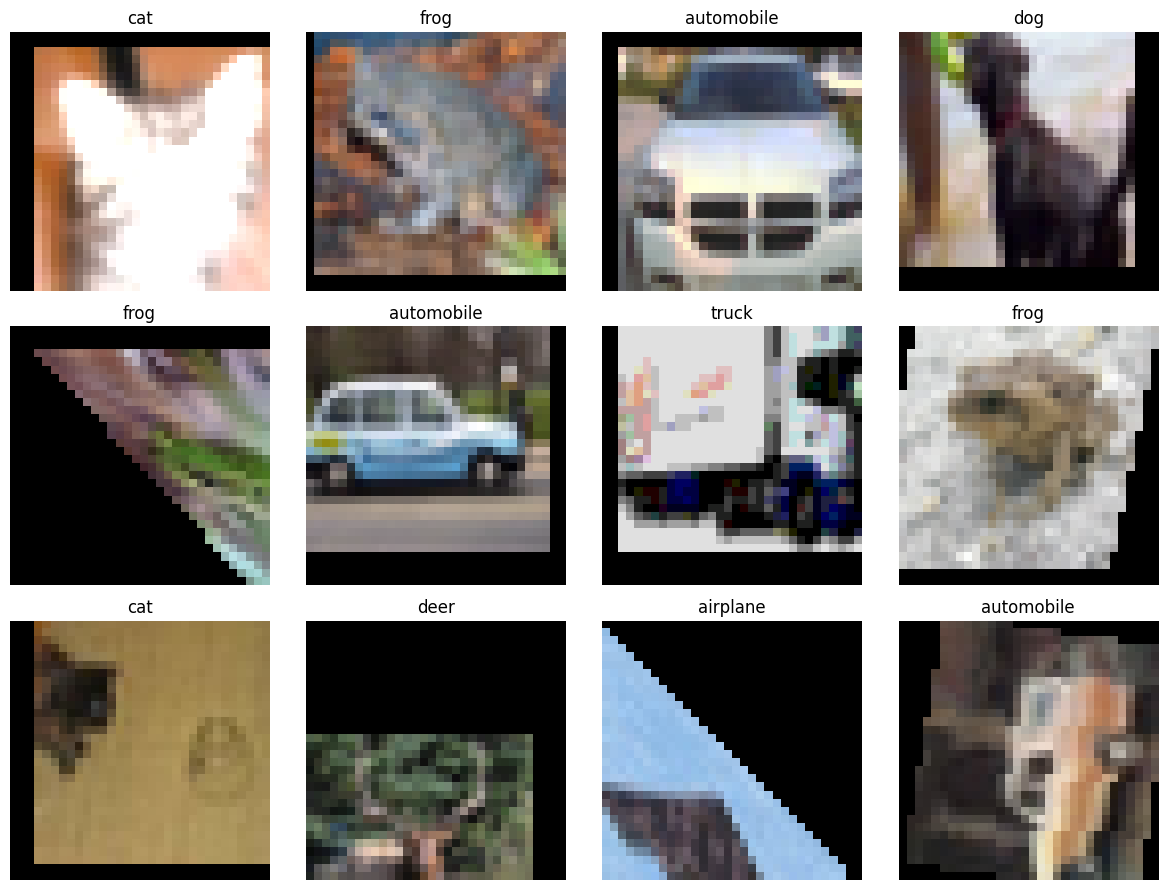

In [4]:
def show_batch(loader, class_names, n=12):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    mean = torch.tensor(CIFAR10_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(1, 3, 1, 1)
    images = (images * std + mean).clamp(0, 1)

    cols = 4
    rows = math.ceil(n / cols)
    plt.figure(figsize=(12, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].permute(1, 2, 0))
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_batch(train_loader, class_names)

## Vision Transformer (Custom Implementation)

The structure mirrors your Seq2Seq transformer style:
- custom multi-head attention
- explicit encoder block modules
- clean forward pass through helper methods

In [5]:
# GPU-friendly defaults for your RTX 5070 (12 GB).
PATCH_SIZE = 4
EMBED_DIM = 384 if device.type == "cuda" else 256
DEPTH = 8 if device.type == "cuda" else 6
NUM_HEADS = 8
MLP_RATIO = 4
DROPOUT = 0.1
ATTN_DROPOUT = 0.1

print("PATCH_SIZE:", PATCH_SIZE)
print("EMBED_DIM:", EMBED_DIM)
print("DEPTH:", DEPTH)
print("NUM_HEADS:", NUM_HEADS)

PATCH_SIZE: 4
EMBED_DIM: 384
DEPTH: 8
NUM_HEADS: 8


In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=384):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        x = self.proj(x)               # (B, embed_dim, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Custom multi-head self-attention (ViT style)."""
    def __init__(self, d_model, num_heads, attn_dropout=0.0, proj_dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(d_model, d_model)
        self.proj_drop = nn.Dropout(proj_dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        Q, K, V = qkv[0], qkv[1], qkv[2]

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = scores.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ V).transpose(1, 2).reshape(B, N, C)
        out = self.proj_drop(self.proj(out))
        return out


class MLP(nn.Module):
    def __init__(self, d_model, mlp_ratio=4, dropout=0.0):
        super().__init__()
        hidden_dim = int(d_model * mlp_ratio)
        self.fc1 = nn.Linear(d_model, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, mlp_ratio=4, dropout=0.0, attn_dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(
            d_model,
            num_heads,
            attn_dropout=attn_dropout,
            proj_dropout=dropout,
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, mlp_ratio=mlp_ratio, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=384,
        depth=8,
        num_heads=8,
        mlp_ratio=4,
        dropout=0.1,
        attn_dropout=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
        )
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                dropout=dropout,
                attn_dropout=attn_dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward_features(self, x):
        x = self.patch_embed(x)
        B = x.size(0)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed[:, :x.size(1)]
        x = self.pos_drop(x)

        for layer in self.encoder_layers:
            x = layer(x)

        x = self.norm(x)
        return x[:, 0]  # class token

    def forward(self, x):
        feats = self.forward_features(x)
        logits = self.head(feats)
        return logits


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Training And Evaluation Helpers

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def fit(model, train_loader, val_loader, epochs, lr=3e-4, weight_decay=0.05):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.95),
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return history, best_val_acc


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Train")
    plt.plot(epochs, history["val_loss"], marker="s", label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="Train")
    plt.plot(epochs, history["val_acc"], marker="s", label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Build The ViT Model

In [8]:
model = VisionTransformer(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=3,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    attn_dropout=ATTN_DROPOUT,
).to(device)

print(f"Trainable params: {count_parameters(model) / 1e6:.3f}M")

# Quick shape sanity check.
with torch.no_grad():
    x_dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=device)
    y_dummy = model(x_dummy)
print("Output shape:", y_dummy.shape)

Trainable params: 14.244M
Output shape: torch.Size([2, 10])


## Train The Model

C:\Users\shamb\AppData\Local\Temp\ipykernel_18404\792886668.py:66: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Train:   0%|          | 0/176 [00:00<?, ?it/s]

Eval:   0%|          | 0/20 [00:16<?, ?it/s]

Epoch 01/25 | train_loss=2.0878, train_acc=0.2411 | val_loss=1.8808, val_acc=0.3386


Train:   0%|          | 0/176 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 24/25 | train_loss=1.3082, train_acc=0.6319 | val_loss=1.1241, val_acc=0.7226


Train:   0%|          | 0/176 [00:00<?, ?it/s]

Eval:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 25/25 | train_loss=1.3017, train_acc=0.6333 | val_loss=1.1227, val_acc=0.7242
Best validation accuracy: 0.7264


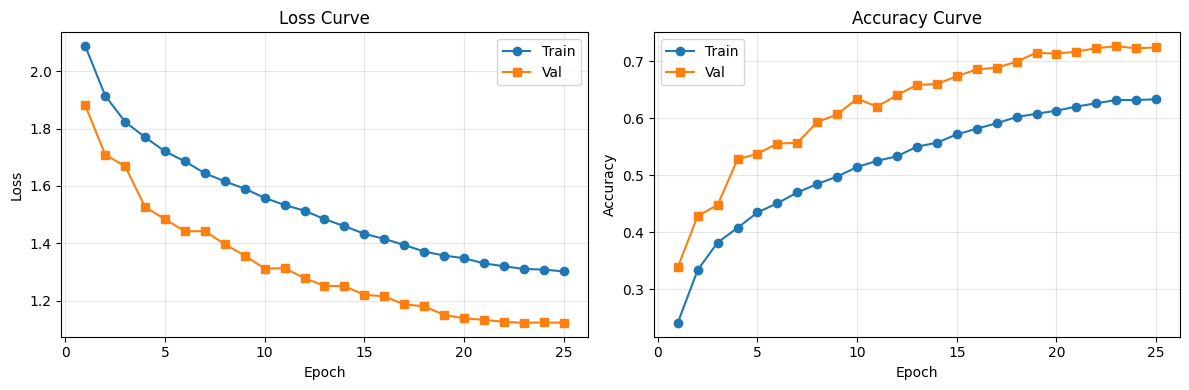

In [9]:
# Recommended range on your RTX 5070: 20-35 epochs.
EPOCHS = 25 if device.type == "cuda" else 10
LR = 3e-4
WEIGHT_DECAY = 0.05

history, best_val_acc = fit(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

print(f"Best validation accuracy: {best_val_acc:.4f}")
plot_history(history)

## Evaluate On Test Set

Eval:   0%|          | 0/40 [00:22<?, ?it/s]

Test loss: 0.8391
Test accuracy: 0.7202


Confusion:   0%|          | 0/40 [00:00<?, ?it/s]

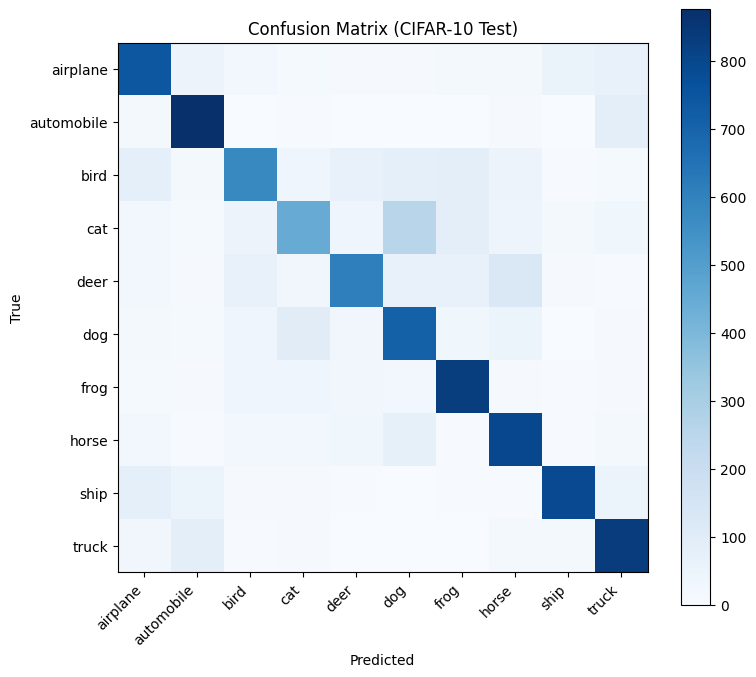

In [10]:
criterion_eval = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion_eval)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Confusion matrix
cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Confusion", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(images)

        preds = logits.argmax(dim=1)
        for t, p in zip(labels.view(-1), preds.view(-1)):
            cm[t.long(), p.long()] += 1

cm_np = cm.numpy()
plt.figure(figsize=(8, 7))
plt.imshow(cm_np, cmap="Blues")
plt.title("Confusion Matrix (CIFAR-10 Test)")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Sample Predictions

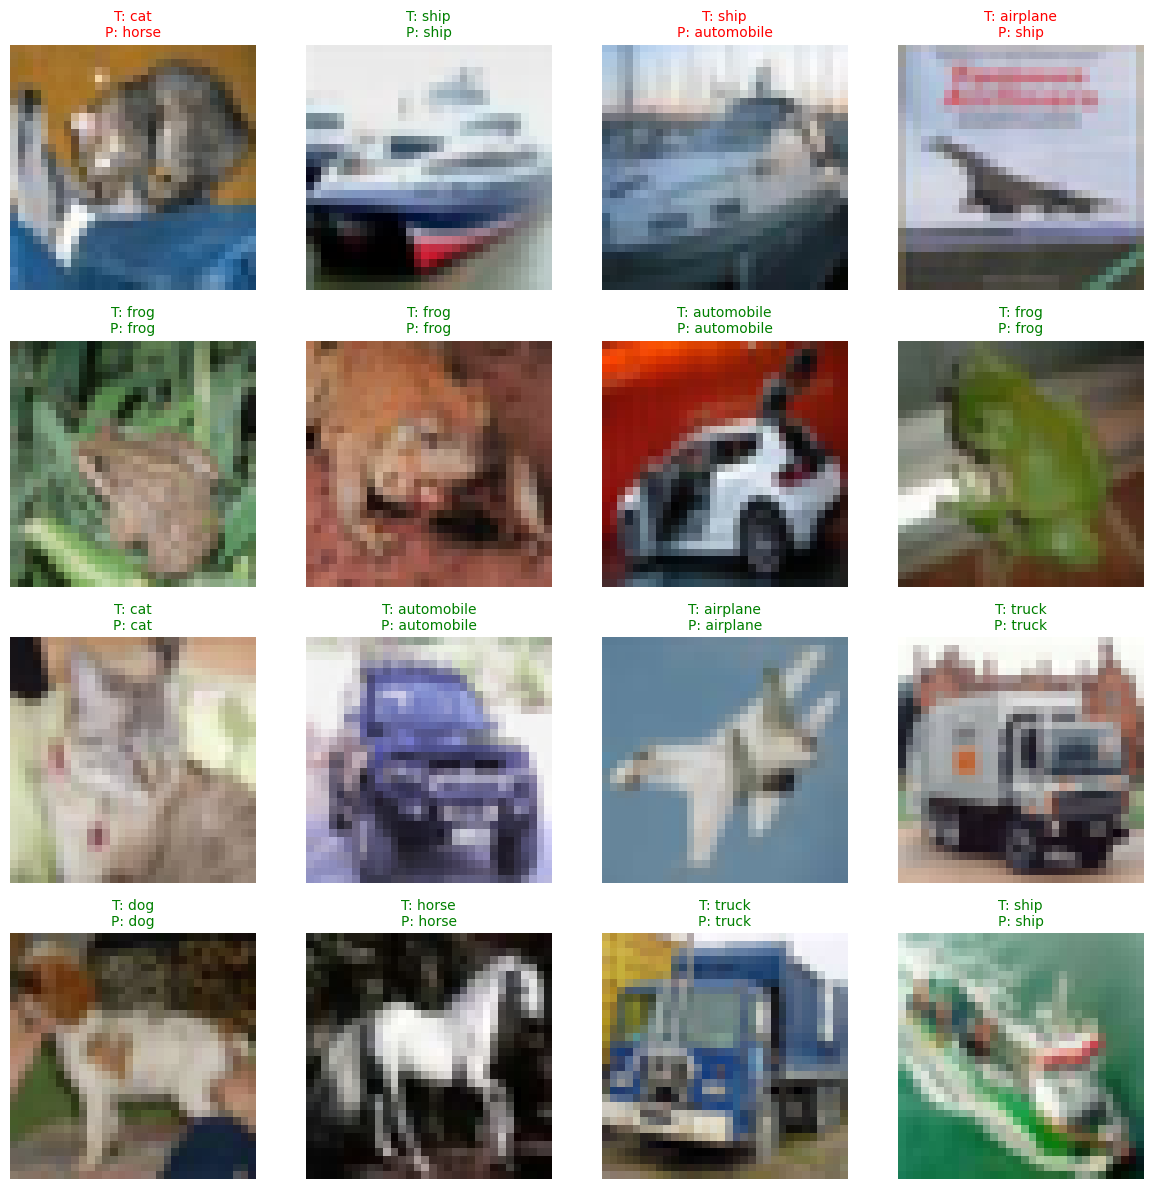

In [11]:
@torch.no_grad()
def show_predictions(model, loader, class_names, n=16):
    model.eval()
    images, labels = next(iter(loader))
    images = images[:n].to(device)
    labels = labels[:n].to(device)

    with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
        logits = model(images)
    preds = logits.argmax(dim=1)

    images_cpu = images.detach().cpu()
    labels_cpu = labels.detach().cpu()
    preds_cpu = preds.detach().cpu()

    mean = torch.tensor(CIFAR10_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(1, 3, 1, 1)
    images_cpu = (images_cpu * std + mean).clamp(0, 1)

    cols = 4
    rows = math.ceil(n / cols)
    plt.figure(figsize=(12, 3 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images_cpu[i].permute(1, 2, 0))
        true_name = class_names[labels_cpu[i].item()]
        pred_name = class_names[preds_cpu[i].item()]
        color = "green" if true_name == pred_name else "red"
        plt.title(f"T: {true_name}\nP: {pred_name}", color=color, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(model, test_loader, class_names, n=16)

## Notes

- This is a compact ViT suited for CIFAR-10 and your local GPU.
- If GPU memory allows and you want better accuracy, increase `DEPTH` to 10 and `EMBED_DIM` to 512.
- If training is slow, reduce `EPOCHS` first, then `EMBED_DIM`.